In [1]:
import bilby
import numpy as np
import matplotlib.pyplot as plt
# import ringdown
from scipy.linalg import toeplitz, inv
import scipy.signal as sig
from pycbc.detector import Detector
import dill
from scipy.signal import welch
from gwpy.timeseries import TimeSeries
from gwosc.datasets import event_gps
from scipy.signal.windows import tukey
from pycbc.filter import highpass, lowpass

/opt/miniconda3/envs/LALSuite_edited/lib/python3.13/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


# Correlating noise in time domain to get ACF:

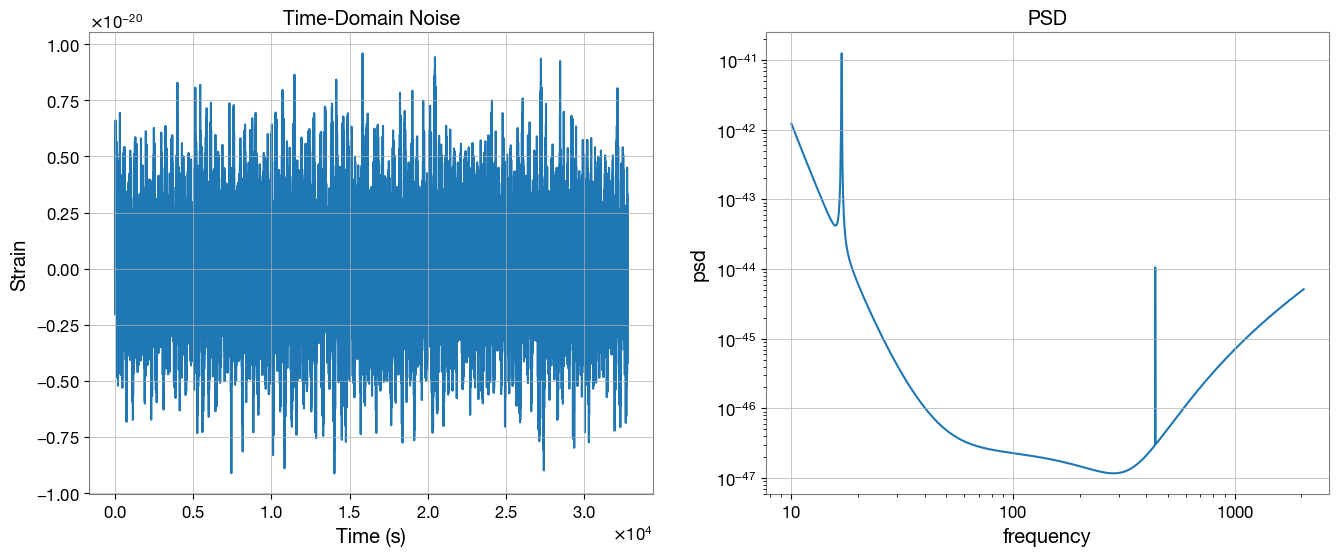

In [2]:
ifo = bilby.gw.detector.get_empty_interferometer("V1")
# ifo.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(psd_file="aLIGO_psd_padded_2.txt")
ifo.minimum_frequency = 0

duration = 8 # seconds
sampling_frequency = 4096  # Hz

ifo.set_strain_data_from_power_spectral_density(
    sampling_frequency=sampling_frequency,
    duration=duration
)
time_series = ifo.time_array
noise_series = ifo.strain_data.time_domain_strain
psd = ifo.power_spectral_density_array
freq = ifo.frequency_array
# idx = np.where(freq>=ifo.minimum_frequency)[0]
# freq = freq[idx]
# psd = psd[idx]

# idx2 = np.where(psd==np.inf)[0]
# psd_2 = psd.copy()
# psd_2[idx2] = 0
# psd_2[idx2] = 100*np.max(psd_2)
# print(np.max(psd_2))

fig,ax = plt.subplots(1,2,figsize=(16,6))
ax[0].plot(noise_series)
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Strain")
ax[0].set_title("Time-Domain Noise")

ax[1].plot(freq,psd)
ax[1].set_xlabel("frequency")
ax[1].set_ylabel("psd")
ax[1].set_title("PSD")
ax[1].set_xscale("log")
ax[1].set_yscale("log")

In [3]:
# frequencies = freq.copy()
# psd_values = psd_2.copy()

In [4]:
# psd_table = np.column_stack((frequencies, psd_values))
# np.savetxt("aLIGO_psd.txt", psd_table, fmt="%.6e")

In [5]:
def compute_autocorrelation(d):
    """
    d : 1D array
        Input time-domain signal (strain data or noise).
    n : int
        Number of points in the output correlation function.
    """
    n = len(d)
    rho = sig.correlate(d, d)
    rho = np.fft.ifftshift(rho)
    rho = rho[:n] / len(d)
    return rho

Interferometer(name='L1', power_spectral_density=PowerSpectralDensity(psd_file='None', asd_file='/opt/miniconda3/envs/LALSuite_edited/lib/python3.13/site-packages/bilby/gw/detector/noise_curves/aLIGO_O4_high_asd.txt'), minimum_frequency=0.0, maximum_frequency=2048.0, length=4.0, latitude=30.562894333333332, longitude=-90.77424038888887, elevation=-6.574, xarm_azimuth=197.7165, yarm_azimuth=287.7165, xarm_tilt=-0.0003121, yarm_tilt=-0.0006107)
Interferometer(name='H1', power_spectral_density=PowerSpectralDensity(psd_file='None', asd_file='/opt/miniconda3/envs/LALSuite_edited/lib/python3.13/site-packages/bilby/gw/detector/noise_curves/aLIGO_O4_high_asd.txt'), minimum_frequency=0.0, maximum_frequency=2048.0, length=4.0, latitude=46.45514666666667, longitude=-119.4076571388889, elevation=142.554, xarm_azimuth=125.9994, yarm_azimuth=215.9994, xarm_tilt=-0.0006195, yarm_tilt=1.25e-05)
Interferometer(name='V1', power_spectral_density=PowerSpectralDensity(psd_file='/opt/miniconda3/envs/LALSuit

Text(0, 0.5, 'ACF')

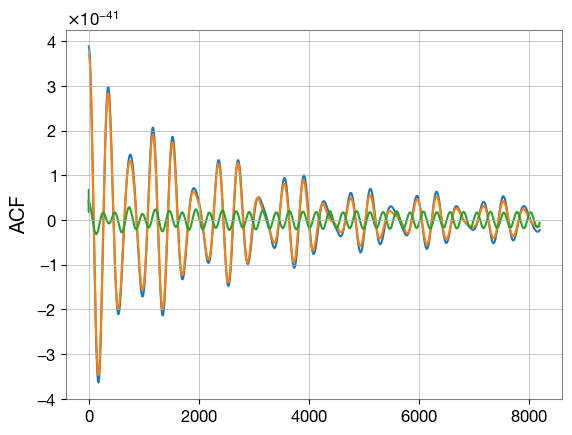

In [6]:
Detectors_list = {"L1":Detector("L1"),"H1":Detector("H1"), "V1":Detector("V1")}

C_inv = {}
Noise = {}
ACF_dict = {}

length_of_noise_segment = 1024 # seconds
sampling_frequency = 4096  # Hz

duration = 2 # seconds of data

for k in Detectors_list.keys():
    ifo = bilby.gw.detector.get_empty_interferometer(k)
    # ifo.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(psd_file="aLIGO_psd_padded_2.txt")
    ifo.minimum_frequency = 0
    print(ifo)

    ifo.set_strain_data_from_power_spectral_density(
        sampling_frequency=sampling_frequency,
        duration=length_of_noise_segment
    )

    time_series = ifo.time_array
    noise_series = ifo.strain_data.time_domain_strain
    ACF = compute_autocorrelation(noise_series)

    C_inv[k] = inv(toeplitz(ACF[0:duration*4096]))
    Noise[k] = noise_series[0:duration*4096]
    ACF_dict[k] = ACF[0:duration*4096]
    plt.plot(ACF_dict[k],label = k)

# plt.xlabel("time (seconds)")
plt.ylabel("ACF")

# Inv_cov_Noise = {"C_inv": C_inv, "Noise": Noise, "ACF":ACF_dict}
# with open("C_inv_" + str(duration) + "_sec.pkl", "wb") as f:
#     dill.dump(Inv_cov_Noise, f)

# Constructing ACF using psd

In [7]:
def acf_from_psd(psd_data,fs,N):
    delta_t = 1/fs
    rho = 0.5 * np.real(np.fft.irfft(a=psd_data,)) / (delta_t)
    return rho

Interferometer(name='L1', power_spectral_density=PowerSpectralDensity(psd_file='None', asd_file='/opt/miniconda3/envs/LALSuite_edited/lib/python3.13/site-packages/bilby/gw/detector/noise_curves/aLIGO_O4_high_asd.txt'), minimum_frequency=0.0, maximum_frequency=2048.0, length=4.0, latitude=30.562894333333332, longitude=-90.77424038888887, elevation=-6.574, xarm_azimuth=197.7165, yarm_azimuth=287.7165, xarm_tilt=-0.0003121, yarm_tilt=-0.0006107)
Interferometer(name='H1', power_spectral_density=PowerSpectralDensity(psd_file='None', asd_file='/opt/miniconda3/envs/LALSuite_edited/lib/python3.13/site-packages/bilby/gw/detector/noise_curves/aLIGO_O4_high_asd.txt'), minimum_frequency=0.0, maximum_frequency=2048.0, length=4.0, latitude=46.45514666666667, longitude=-119.4076571388889, elevation=142.554, xarm_azimuth=125.9994, yarm_azimuth=215.9994, xarm_tilt=-0.0006195, yarm_tilt=1.25e-05)
Interferometer(name='V1', power_spectral_density=PowerSpectralDensity(psd_file='/opt/miniconda3/envs/LALSuit

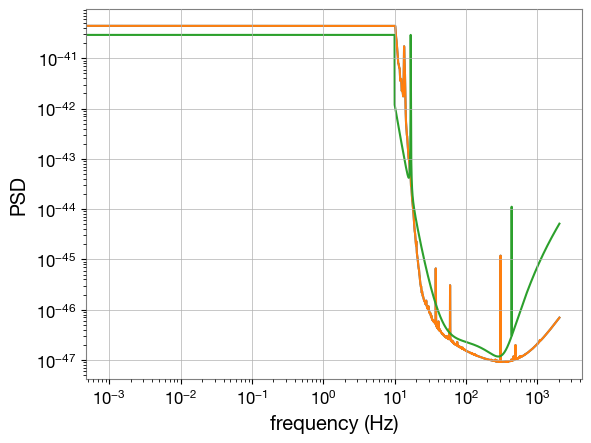

In [8]:
Detectors_list = {"L1":Detector("L1"),"H1":Detector("H1"), "V1":Detector("V1")}

C_inv = {}
Noise = {}
ACF_dict = {}

length_of_noise_segment = 1024 # seconds
sampling_frequency = 4096  # Hz

duration = 16 # seconds of data

for k in Detectors_list.keys():
    ifo = bilby.gw.detector.get_empty_interferometer(k)
    # ifo.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(psd_file="aLIGO_psd_padded_2.txt")
    ifo.minimum_frequency = 0
    print(ifo)

    ifo.set_strain_data_from_power_spectral_density(
        sampling_frequency=sampling_frequency,
        duration=length_of_noise_segment
    )
    
    time_series = ifo.time_array
    noise_series = ifo.strain_data.time_domain_strain
    psd = ifo.power_spectral_density_array
    freq = ifo.frequency_array
    idx = np.where(freq>=10)[0]
    # freq = freq[idx]
    # psd = ifo.power_spectral_density_array
    idx2 = np.where(psd==np.inf)[0]
    psd[idx2] = 0
    psd[idx2] = np.max(psd)
    plt.loglog(freq,psd)
    ACF = acf_from_psd(psd,4096,1)
    ACF_dict[k] = ACF[:duration*sampling_frequency]

    # C_inv[k] = inv(toeplitz(ACF[0:duration*4096]))
    # Noise[k] = noise_series[0:duration*4096]

# plt.xlabel("time (seconds)")
# plt.ylabel("ACF")

plt.xlabel("frequency (Hz)")
plt.ylabel("PSD")
    
Inv_cov_Noise = {"C_inv": C_inv, "Noise": Noise}
with open("C_inv_" + str(duration) + "_sec_using_bilby_fmin_10_hz_fft.pkl", "wb") as f:
    dill.dump(Inv_cov_Noise, f)

# Inverse of circulant matrix:

In [9]:
import numpy as np
from scipy.linalg import circulant
from scipy.fft import fft, ifft

def inverse_circulant_first_row(c):
    eigenvalues = fft(c)
    if np.any(eigenvalues == 0):
        raise ValueError("The matrix is singular and does not have an inverse.")
    inv_eigenvalues = 1 / eigenvalues
    c_inv_first_row = ifft(inv_eigenvalues).real
    return c_inv_first_row

    
Detectors_list = {"L1":Detector("L1"),"H1":Detector("H1")}

In [10]:
length_of_noise_segment = 128 # seconds
sampling_frequency = 4096  # Hz
C_inv_row = {}
C_inv = {}
Noise = {}

for k in Detectors_list.keys():
    ifo = bilby.gw.detector.get_empty_interferometer(k)
    # ifo.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(psd_file="aLIGO_psd_padded_2.txt")
    ifo.minimum_frequency = 0
    print(ifo)

    ifo.set_strain_data_from_power_spectral_density(
        sampling_frequency=sampling_frequency,
        duration=length_of_noise_segment
    )

    time_series = ifo.time_array
    noise_series = ifo.strain_data.time_domain_strain
    psd = ifo.power_spectral_density_array
    freq = ifo.frequency_array
    idx2 = np.where(psd==np.inf)[0]
    psd[idx2] = 0
    psd[idx2] = np.max(psd)
    ACF = acf_from_psd(psd,4096,1)
    C_inv_row[k] = inverse_circulant_first_row(ACF)
    Noise[k] = noise_series

# Inv_cov_Noise = {"C_inv": C_inv_row, "Noise": Noise}
# with open("C_inv_row_" + str(length_of_noise_segment) + "_sec.pkl", "wb") as f:
#     dill.dump(Inv_cov_Noise, f)

Interferometer(name='L1', power_spectral_density=PowerSpectralDensity(psd_file='None', asd_file='/opt/miniconda3/envs/LALSuite_edited/lib/python3.13/site-packages/bilby/gw/detector/noise_curves/aLIGO_O4_high_asd.txt'), minimum_frequency=0.0, maximum_frequency=2048.0, length=4.0, latitude=30.562894333333332, longitude=-90.77424038888887, elevation=-6.574, xarm_azimuth=197.7165, yarm_azimuth=287.7165, xarm_tilt=-0.0003121, yarm_tilt=-0.0006107)
Interferometer(name='H1', power_spectral_density=PowerSpectralDensity(psd_file='None', asd_file='/opt/miniconda3/envs/LALSuite_edited/lib/python3.13/site-packages/bilby/gw/detector/noise_curves/aLIGO_O4_high_asd.txt'), minimum_frequency=0.0, maximum_frequency=2048.0, length=4.0, latitude=46.45514666666667, longitude=-119.4076571388889, elevation=142.554, xarm_azimuth=125.9994, yarm_azimuth=215.9994, xarm_tilt=-0.0006195, yarm_tilt=1.25e-05)


Text(0, 0.5, 'ACF')

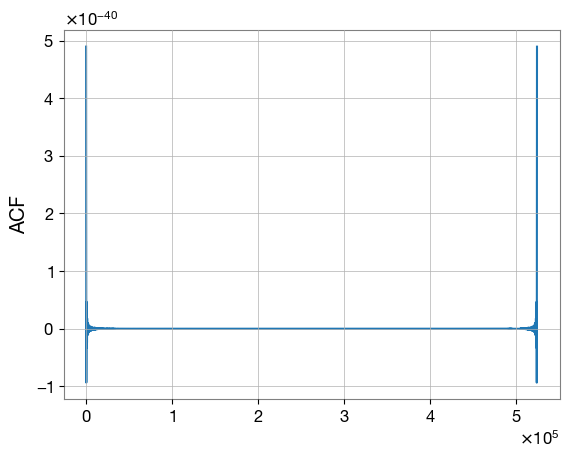

In [11]:
plt.plot(ACF)
plt.ylabel("ACF")

# Virgo:

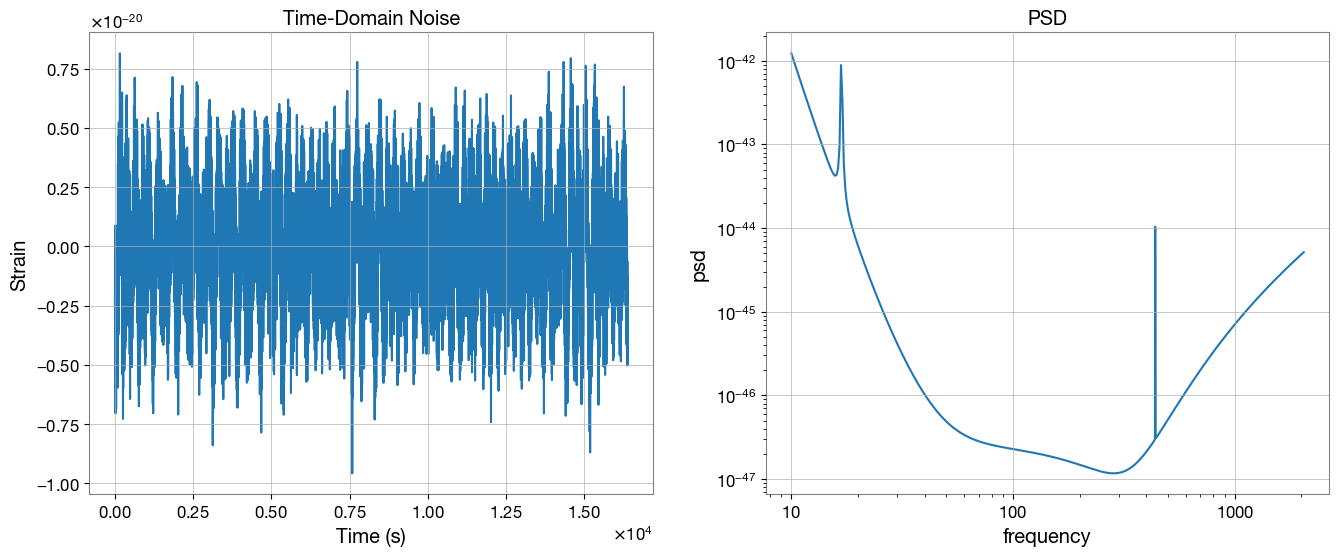

In [12]:
ifo = bilby.gw.detector.get_empty_interferometer("V1")
# ifo.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(psd_file="aVirgo_psd.txt")
ifo.minimum_frequency = 0

duration = 4 # seconds
sampling_frequency = 4096  # Hz

ifo.set_strain_data_from_power_spectral_density(
    sampling_frequency=sampling_frequency,
    duration=duration
)
time_series = ifo.time_array
noise_series = ifo.strain_data.time_domain_strain
psd = ifo.power_spectral_density_array
freq2 = ifo.frequency_array
idx2 = np.where(psd==np.inf)[0]
psd_2 = psd.copy()
psd_2[idx2] = 0
psd_2[idx2] = np.max(psd_2)

fig,ax = plt.subplots(1,2,figsize=(16,6))
ax[0].plot(noise_series)
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Strain")
ax[0].set_title("Time-Domain Noise")

ax[1].plot(freq2,psd)
ax[1].set_xlabel("frequency")
ax[1].set_ylabel("psd")
ax[1].set_title("PSD")
ax[1].set_xscale("log")
ax[1].set_yscale("log")